## Polynomial Regression using PyTorch

### Objective:

Use PyTorch's nn.Module API to build a polynomial regression model that learns patterns from a CSV dataset and measures its performance through regression metrics.

In [1]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 2. Load the dataset

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


### 3. Data Preparation as PyTorch Tensors

In [23]:
import torch

X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)

print(X.shape)
print(y.shape)



torch.Size([50, 1])
torch.Size([50, 1])


### 4. Split the dataset

In [24]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### 5. Visualize training and testing data

In [25]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

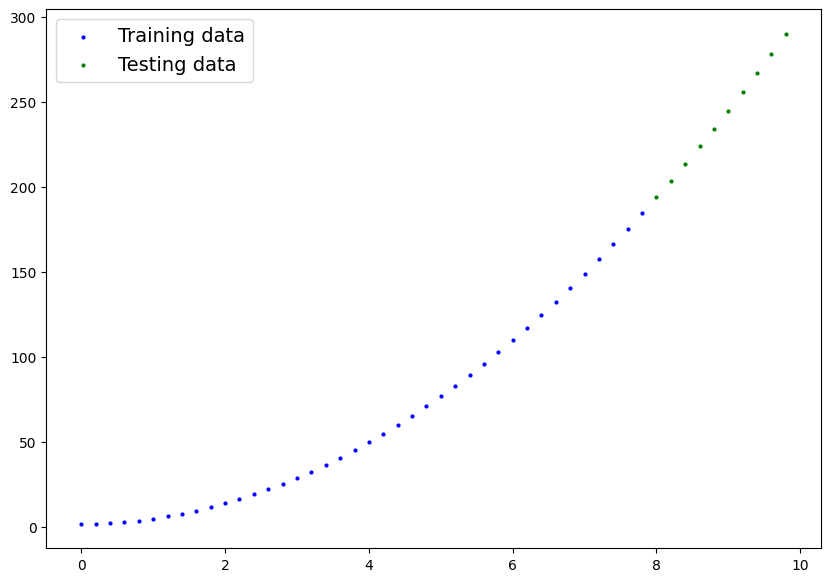

In [26]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

### Algorithm Selection

A custom Linear Regression model was developed using PyTorch by extending the nn.Module class. The model includes two learnable parameters, namely the weight and bias, which are initialized randomly and defined using nn.Parameter. These parameters are automatically optimized during the training process through gradient descent to minimize the prediction error. The forward() method specifies the relationship between the input features and the output predictions by implementing the linear regression equation.


### 6. Create a Linear Regression model class

In [ ]:
# Create a linearregressionmodel model class
class LinearRegressionModelModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
#class Model(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x**2 + self.bias # <- this is the linear regression formula (y = m*x + b)

### PyTorch Model Building Essentials

* torch.nn - Provides layers, activation functions, and loss functions for building neural networks.
* torch.nn.Parameter- A learnable tensor whose values are updated during training.
* torch.nn.Module - The base class for creating custom neural network models and layers.
* torch.optim - Contains optimization algorithms (e.g., SGD, Adam) used to update model parameters.
* forward() - Defines how input data passes through the model to produce an output.

### 7. Initialize Model and Inspect Parameters

In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [29]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


### 8. Initial Prediction

In [30]:
 #Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021]])

In [31]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


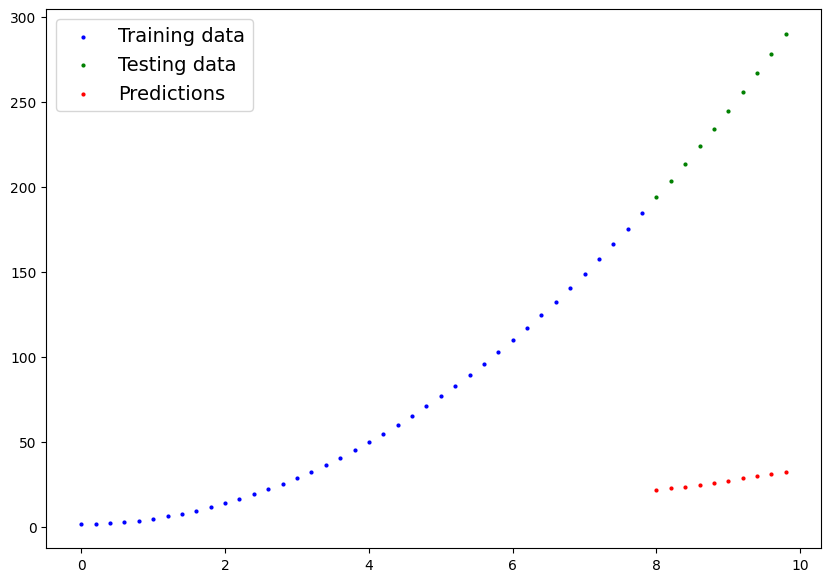

In [32]:
plot_predictions(predictions=y_preds)

### 9. Configure Loss Function and Optimizer


In [33]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


### 10. Training and testing loop
This code trains the model for 100 epochs. In each epoch, the model performs a forward pass to make predictions, computes the loss, and uses backpropagation with an optimizer to update its parameters. The model is then evaluated on the test dataset using eval() and torch.inference_mode() to measure its performance without updating weights. Training and test losses are recorded every 10 epochs to monitor learning progress and detect overfitting

In [34]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 56.5755729675293 | MAE Test Loss: 197.36334228515625 
Epoch: 10 | MAE Train Loss: 14.286410331726074 | MAE Test Loss: 33.888160705566406 
Epoch: 20 | MAE Train Loss: 2.8425636291503906 | MAE Test Loss: 2.050981044769287 
Epoch: 30 | MAE Train Loss: 3.392380475997925 | MAE Test Loss: 0.18432006239891052 
Epoch: 40 | MAE Train Loss: 3.450094699859619 | MAE Test Loss: 0.1851348876953125 
Epoch: 50 | MAE Train Loss: 3.436321973800659 | MAE Test Loss: 0.2010147124528885 
Epoch: 60 | MAE Train Loss: 3.3256192207336426 | MAE Test Loss: 0.6358078122138977 
Epoch: 70 | MAE Train Loss: 3.336348056793213 | MAE Test Loss: 0.5997177362442017 
Epoch: 80 | MAE Train Loss: 3.586681842803955 | MAE Test Loss: 0.4443832337856293 
Epoch: 90 | MAE Train Loss: 3.900193691253662 | MAE Test Loss: 1.460443139076233 


### 11. Plot the loss curves

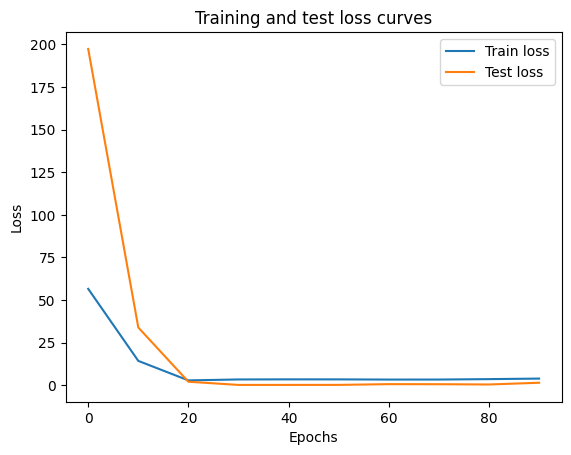

In [35]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [36]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([3.0387]), 'bias': tensor([0.5983])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### 13. Final Prediction

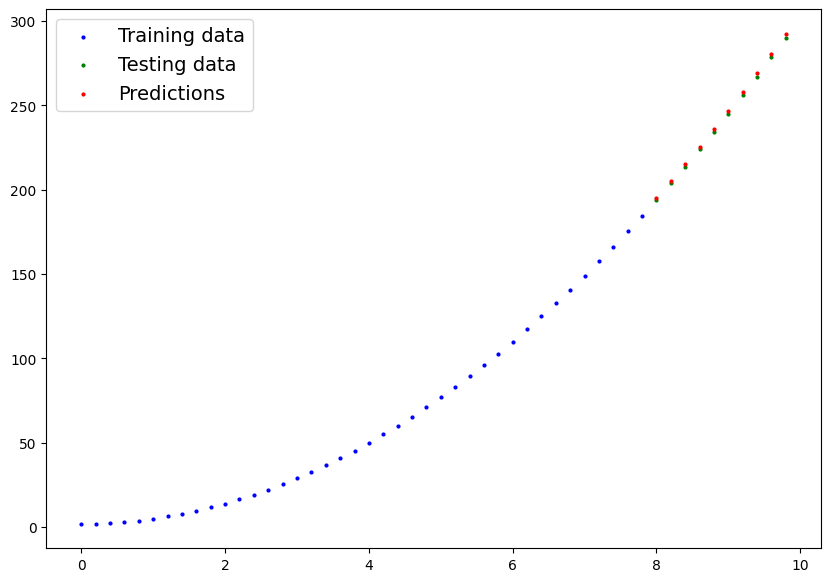

In [37]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Discussion and Conclusion

This experiment provided practical experience in implementing linear regression using PyTorch. The model was constructed by defining trainable weight and bias parameters, which were optimized using the Stochastic Gradient Descent (SGD) algorithm. Initially, the model produced inaccurate predictions due to the random initialization of these parameters. As training progressed, backpropagation and gradient descent continuously adjusted the parameters to minimize the prediction error.

The results showed a substantial decrease in both training and testing losses, indicating that the model effectively captured the relationship between the input and output variables. Furthermore, the learned weight and bias values were very close to the actual parameters used to generate the dataset, demonstrating the accuracy and reliability of the learning process. The loss curves exhibited smooth and stable convergence throughout training suggesting that the optimization procedure was effective and that the model generalized well to unseen data without significant overfitting.
This experiment highlights the fundamental workflow of machine learning in PyTorch, including data preparation, model creation, training, evaluation, and inference.

### Polynomial (quadratic) regression using PyTorch

### Objective:
 To develop a polynomial (quadratic) regression model using PyTorch's nn.Module API. The model is trained on data loaded from a CSV file to learn the coefficients of a quadratic function. During training, the model optimizes its parameters by minimizing the Mean Absolute Error (MAE) loss. 

In [38]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

In [39]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 2. Load the dataset

In [40]:
import pandas as pd
import torch

#df = pd.read_csv(r'linear-regression-data1.csv')
df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


### 3. Data Preparation as PyTorch tensors

In [41]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


### 4. Split the data

In [42]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

### 5. Visualize training and testing data

In [43]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

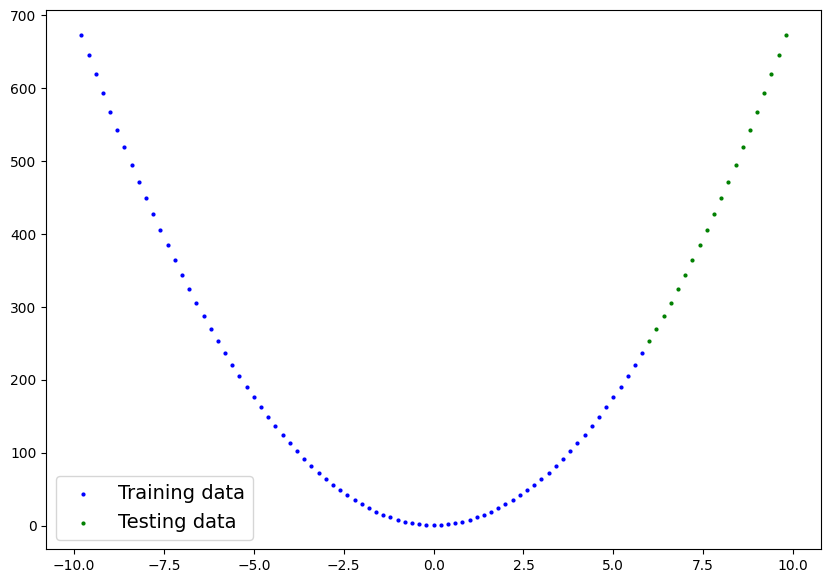

In [44]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

### 6. Create a Linear Regression model class

In [45]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x**2 + self.bias # <- this is the linear regression formula (y = m*x + b)

### 7. Initialize Model and Inspect Parameters

In [46]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [47]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


### 8. Initial Prediction

In [48]:
 #Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974]])

In [49]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[12.2497],
        [13.0712],
        [13.9196],
        [14.7950],
        [15.6974],
        [16.6266],
        [17.5828],
        [18.5660],
        [19.5760],
        [20.6131],
        [21.6770],
        [22.7679],
        [23.8857],
        [25.0304],
        [26.2021],
        [27.4007],
        [28.6263],
        [29.8788],
        [31.1582],
        [32.4646]])


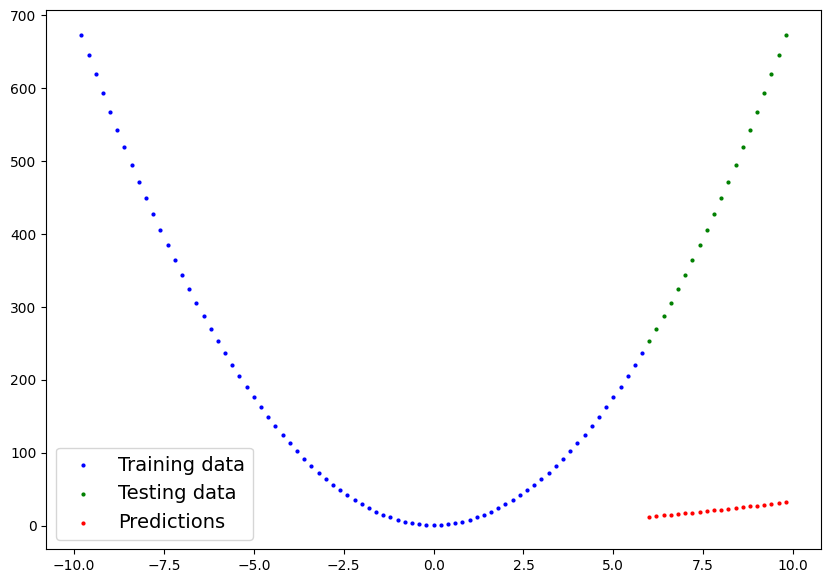

In [50]:
plot_predictions(predictions=y_preds)

### 9. Configure Loss Function and Optimizer

In [51]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### 10. Training and testing loop

In [52]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.12127685546875 | MAE Test Loss: 409.7730407714844 
Epoch: 10 | MAE Train Loss: 104.51728057861328 | MAE Test Loss: 251.5978546142578 
Epoch: 20 | MAE Train Loss: 42.913272857666016 | MAE Test Loss: 93.42262268066406 
Epoch: 30 | MAE Train Loss: 3.944099187850952 | MAE Test Loss: 6.613184928894043 
Epoch: 40 | MAE Train Loss: 2.9400620460510254 | MAE Test Loss: 9.151992797851562 
Epoch: 50 | MAE Train Loss: 2.282644033432007 | MAE Test Loss: 10.805486679077148 
Epoch: 60 | MAE Train Loss: 1.7487810850143433 | MAE Test Loss: 12.143815994262695 
Epoch: 70 | MAE Train Loss: 1.3455159664154053 | MAE Test Loss: 13.149670600891113 
Epoch: 80 | MAE Train Loss: 0.9748930335044861 | MAE Test Loss: 14.072405815124512 
Epoch: 90 | MAE Train Loss: 0.6545260548591614 | MAE Test Loss: 14.867582321166992 


### 11. Plot the loss curves

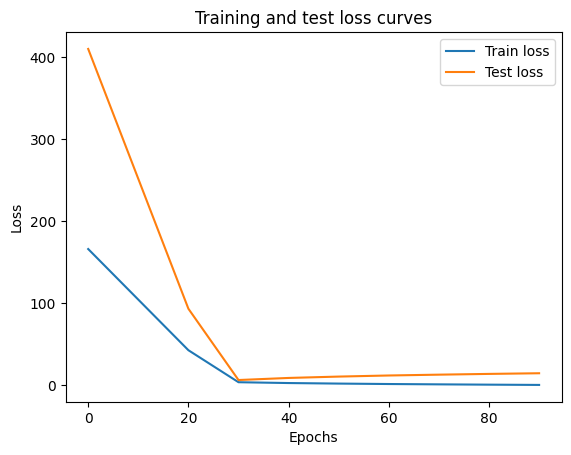

In [53]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### 12. Inspect the learned parameters

In [54]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([7.0016]), 'bias': tensor([0.5501])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### 13. Final Prediction

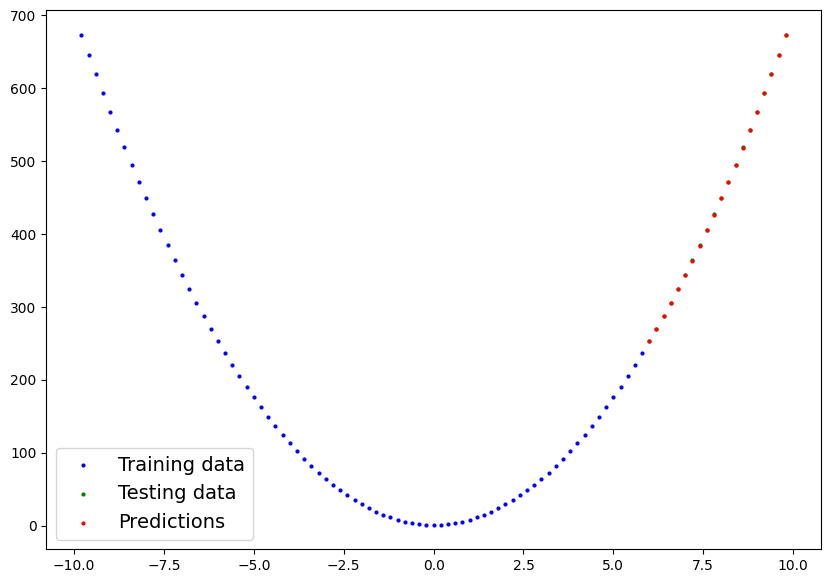

In [55]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Discussion and Conclusion
We learned about how the PyTorch is used for linear regression. The model was built by defining learnable weight and bias parameters and training them using Stochastic Gradient Descent (SGD). At first, the predictions were inaccurate because the parameters were randomly initialized. However, through iterative training and backpropagation, both training and testing losses decreased significantly. It indicates that the model successfully learned the underlying relationship in the data. The learned parameters closely matched the original values used to generate the dataset, demonstrating the effectiveness of gradient-based optimization. The loss curves also showed stable convergence without signs of overfitting.
This experiment highlights the fundamental workflow of machine learning in PyTorch, including data preparation, model creation, training, evaluation, and inference.
